In [1]:
FW_DIR = "../fw/victims/kyber_cpapke_dec_ttest"
BIN_FILE = f"{FW_DIR}/kyber_cpapke_dec_ttest"
BOOTLOADER = "python3 ../../sdk/toolchain/bootloader.py"
BS_FILE = "../vivado/risqrypt_cw305.runs/impl_1/fpga_top.bit"
TARGET_PLATFORM = 'CW305_100t'
KYBER_K = 3

In [2]:
import sys
sys.path.insert(0, "../")

from host.CW305_rq import CW305_rq

In [3]:
import chipwhisperer as cw

In [4]:
scope = cw.scope()
scope.adc.offset = 0
scope.adc.basic_mode = "rising_edge"
scope.trigger.triggers = "tio4"
scope.io.tio1 = "serial_rx"
scope.io.tio2 = "serial_tx"
scope.io.hs2 = "disabled"

In [5]:
target = cw.target(scope, CW305_rq, force=True, fpga_id='100t', platform='cw305', bsfile=BS_FILE)

(ChipWhisperer NAEUSB WARNING|File naeusb.py:800) Your firmware (0.51) is outdated - latest is 0.53 See https://chipwhisperer.readthedocs.io/en/latest/firmware.html for more information


In [6]:
target.vccint_set(1.0)
# we only need PLL1:
target.pll.pll_enable_set(True)
target.pll.pll_outenable_set(False, 0)
target.pll.pll_outenable_set(True, 1)
target.pll.pll_outenable_set(False, 2)

# run at 10 MHz:
target.pll.pll_outfreq_set(10E6, 1)

# 1ms is plenty of idling time
target.clkusbautooff = True
target.clksleeptime = 1

In [7]:
if scope._is_husky:
    scope.clock.clkgen_freq = 40e6
    scope.clock.clkgen_src = 'extclk'
    scope.clock.adc_mul = 4
    # if the target PLL frequency is changed, the above must also be changed accordingly
else:
    scope.clock.adc_src = "extclk_x4"

In [8]:
import time
for i in range(5):
    scope.clock.reset_adc()
    time.sleep(1)
    if scope.clock.adc_locked:
        break 
assert (scope.clock.adc_locked), "ADC failed to lock"

In [9]:
if KYBER_K == 2:
    from kyber_py.kyber.default_parameters import Kyber512 as kyber_py
elif KYBER_K == 3:
    from kyber_py.kyber.default_parameters import Kyber768 as kyber_py
elif KYBER_K == 4:
    from kyber_py.kyber.default_parameters import Kyber1024 as kyber_py
else:
    raise ValueError("Invalid KYBER_K")

In [10]:
import sys

sys.path.append('../../../../../PhD/high_order_non_profiled/scaredcu/')

import scaredcu

In [11]:
target.output_len = 2

In [12]:
import os
from Crypto.Hash import SHA3_256, SHAKE256


kyber_ntt = scaredcu.lbc.kyber.NTT()
poly_compressed_bytes_du = (kyber_py.du*256) // 8
poly_compressed_bytes_dv = (kyber_py.dv*256) // 8
cipher_size = poly_compressed_bytes_du * kyber_py.k + poly_compressed_bytes_dv

def ct_to_poly(ct):
    if KYBER_K == 2:
        poly = scaredcu.lbc.kyber.kyber512_poly_unpack_decompress_du(ct[:poly_compressed_bytes_du])
    elif KYBER_K == 3:
        poly = scaredcu.lbc.kyber.kyber768_poly_unpack_decompress_du(ct[:poly_compressed_bytes_du])
    elif KYBER_K == 4:
        poly = scaredcu.lbc.kyber.kyber1024_poly_unpack_decompress_du(ct[:poly_compressed_bytes_du])
    return kyber_ntt.ntt(poly).get()

def set_ct(seed = os.urandom(16)):
    def rng(len):
        assert len == 32
        return seed
    kyber_py.random_bytes = rng
    target.simpleserial_write('k', seed)
    ct = SHAKE256.new(seed).read(cipher_size)
    ct_dut = target.simpleserial_read('r', 16)
    assert ct[:16] == ct_dut, "Ciphertext mismatch!"
    return ct

def sk_to_poly(sk):
    s_hat = scaredcu.lbc.kyber.decode_sk(sk).get()
    return s_hat

def get_key(seed = os.urandom(32)):
    def rng(len):
        assert len == 32
        return seed
    kyber_py.random_bytes = rng
    _, sk = kyber_py._cpapke_keygen()
    return sk


In [13]:
from tqdm.notebook import tnrange
import numpy as np
import estraces

def collect_traces(N=5000):

    ct = set_ct()
    c = ct_to_poly(ct)

    traces_0 = []
    c_arr_0 = []
    s_arr_0 = []

    traces_1 = []
    c_arr_1 = []
    s_arr_1 = []

    const_seed = os.urandom(32)

    for _ in tnrange(N, desc='Capturing traces'):

        # const input
        ret = cw.capture_trace(scope, target, const_seed, None)
        if not ret:
            print("Failed capture")
            continue
        c_arr_0.append(c)
        sk = get_key(const_seed)
        s = sk_to_poly(sk)
        s_arr_0.append(s)
        m = bytearray(kyber_py._cpapke_dec(sk, ct))
        for i in range(1, len(m)):
            m[0] ^= m[i]
        m_ = bytearray(ret.textout)
        m_[0] = m_[0] ^ m_[1]
        assert m[:1] == m_[:1], "Decrypted message mismatch!"
        traces_0.append(ret.wave)

        # rand input
        seed = os.urandom(32)
        ret = cw.capture_trace(scope, target, seed, None)
        if not ret:
            print("Failed capture")
            continue
        c_arr_1.append(c)
        sk = get_key(seed)
        s = sk_to_poly(sk)
        s_arr_1.append(s)
        m = bytearray(kyber_py._cpapke_dec(sk, ct))
        for i in range(1, len(m)):
            m[0] ^= m[i]
        m_ = bytearray(ret.textout)
        m_[0] = m_[0] ^ m_[1]
        assert m[:1] == m_[:1], "Decrypted message mismatch!"
        traces_1.append(ret.wave)



    ths_0 = estraces.read_ths_from_ram(np.array(traces_0), s=np.array(s_arr_0), c=np.array(c_arr_0))
    ths_1 = estraces.read_ths_from_ram(np.array(traces_1), s=np.array(s_arr_1), c=np.array(c_arr_1))

    print(ths_0)
    print(ths_1)

    return ths_0, ths_1

# PRNG=OFF

In [14]:
%%bash -s "$FW_DIR" "$KYBER_K"
cd $1
make KYBER_K=$2 PRNG_OFF=1

-DKYBER_K=3 -DPRNG_OFF -DSS_VER=1 -O3 -I../../../../fw/kyber_hw -I../../driver -I../../simpleserial -I../../../../sdk/lib -march=rv32im -mabi=ilp32 -mstrict-align -T ../../../../sdk/toolchain/linksc.ld -flto -ffunction-sections -fdata-sections -nostartfiles -o kyber_cpapke_dec_ttest.elf
/opt/riscv/bin/riscv64-unknown-elf-gcc kyber_cpapke_dec_ttest.c ../../../../fw/kyber_hw/indcpa.c ../../../../fw/kyber_hw/poly.c ../../../../fw/kyber_hw/polyvec.c ../../../../fw/kyber_hw/pack.c ../../../../fw/kyber_hw/symmetric.c ../../../../fw/kyber_hw/cbd.c ../../../../fw/kyber_hw/masked_indcpa.c ../../../../fw/kyber_hw/masked_poly.c ../../../../fw/kyber_hw/masked_polyvec.c ../../../../fw/kyber_hw/masked_symmetric.c ../../../../fw/kyber_hw/masked_cbd.c ../../../../fw/kyber_hw/masked_gadgets.c ../../driver/cw305.c ../../simpleserial/simpleserial_cw305_rq.c ../../../../sdk/toolchain/start.s ../../../../sdk/lib/util.c ../../../../sdk/lib/uart.c ../../../../sdk/lib/timer.c ../../../../sdk/lib/gpio.c ../../

In [15]:
%%bash -s "$BIN_FILE" "$BOOTLOADER"
$2 -f $1 -q

Successfully connected to /dev/ttyUSB0
Sent: -p
Waiting for opcodes...
Sending file: ../fw/victims/kyber_cpapke_dec_ttest/kyber_cpapke_dec_ttest.inst.bin


../fw/victims/kyber_cpapke_dec_ttest/kyber_cpapke_dec_ttest.inst.bin: 100%|██████████| 8.65k/8.65k [00:08<00:00, 1.05kB/s]


File transmission complete for ../fw/victims/kyber_cpapke_dec_ttest/kyber_cpapke_dec_ttest.inst.bin.
Sending file: ../fw/victims/kyber_cpapke_dec_ttest/kyber_cpapke_dec_ttest.data.bin


../fw/victims/kyber_cpapke_dec_ttest/kyber_cpapke_dec_ttest.data.bin: 100%|██████████| 1.57k/1.57k [00:01<00:00, 866B/s]


File transmission complete for ../fw/victims/kyber_cpapke_dec_ttest/kyber_cpapke_dec_ttest.data.bin.
Program load complete.
Serial port closed.


In [16]:
scope.adc.samples = 70000
scope.gain.db = 12

In [17]:
ths_0, ths_1 = collect_traces(N=1000)

Capturing traces:   0%|          | 0/1000 [00:00<?, ?it/s]

Trace Header Set:
Name.............: RAM Format THS
Reader...........: RAM reader with 1000 traces. Samples shape: (1000, 70000) and metadatas: ['s', 'c']
s................: uint16
c................: uint16

Trace Header Set:
Name.............: RAM Format THS
Reader...........: RAM reader with 1000 traces. Samples shape: (1000, 70000) and metadatas: ['s', 'c']
s................: uint16
c................: uint16



/home/toluntosun/miniconda3/envs/sca/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


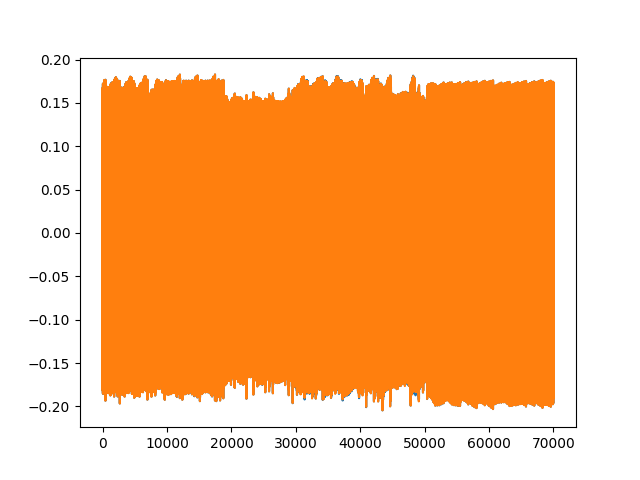

In [19]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots()

%matplotlib widget

mean_trace_0 = np.mean(np.array(ths_0.samples[:]), axis=0)
mean_trace_1 = np.mean(np.array(ths_1.samples[:]), axis=0)
ax.plot(mean_trace_0)
ax.plot(mean_trace_1)

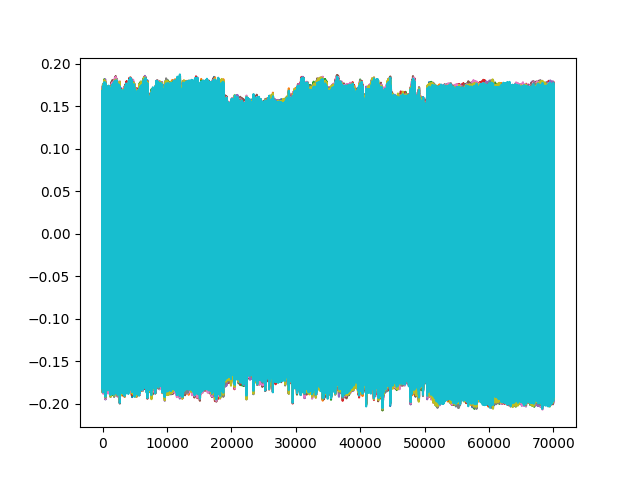

In [20]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots()

for i in range(5):
    ax.plot(ths_0.samples[i])

for i in range(5):
    ax.plot(ths_1.samples[i])

In [21]:
import scared

ttest = scared.ttest.TTestAnalysis()

container = scared.TTestContainer(ths_0, ths_1)

ttest.run(container)

/home/toluntosun/miniconda3/envs/sca/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


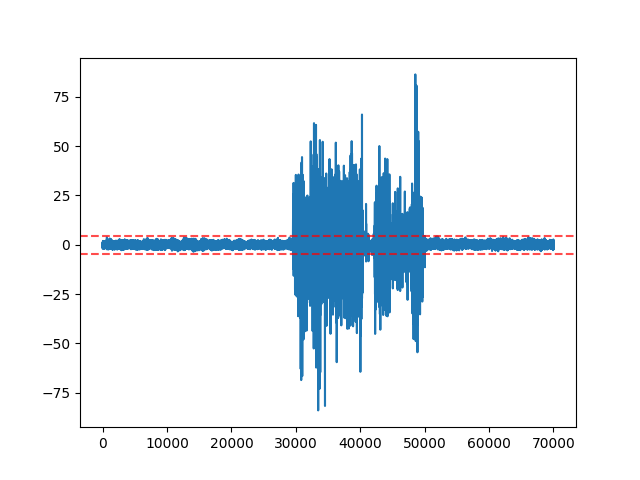

In [22]:
from matplotlib import pyplot as plt

%matplotlib widget

fig, ax = plt.subplots()

ax.plot(ttest.result)
ax.axhline(y=4.5, color='red', linestyle='--', alpha=0.7)
ax.axhline(y=-4.5, color='red', linestyle='--', alpha=0.7)

# PRNG=ON

In [23]:
%%bash -s "$FW_DIR" "$KYBER_K"
cd $1
make KYBER_K=$2

-DKYBER_K=3 -DSS_VER=1 -O3 -I../../../../fw/kyber_hw -I../../driver -I../../simpleserial -I../../../../sdk/lib -march=rv32im -mabi=ilp32 -mstrict-align -T ../../../../sdk/toolchain/linksc.ld -flto -ffunction-sections -fdata-sections -nostartfiles -o kyber_cpapke_dec_ttest.elf
/opt/riscv/bin/riscv64-unknown-elf-gcc kyber_cpapke_dec_ttest.c ../../../../fw/kyber_hw/indcpa.c ../../../../fw/kyber_hw/poly.c ../../../../fw/kyber_hw/polyvec.c ../../../../fw/kyber_hw/pack.c ../../../../fw/kyber_hw/symmetric.c ../../../../fw/kyber_hw/cbd.c ../../../../fw/kyber_hw/masked_indcpa.c ../../../../fw/kyber_hw/masked_poly.c ../../../../fw/kyber_hw/masked_polyvec.c ../../../../fw/kyber_hw/masked_symmetric.c ../../../../fw/kyber_hw/masked_cbd.c ../../../../fw/kyber_hw/masked_gadgets.c ../../driver/cw305.c ../../simpleserial/simpleserial_cw305_rq.c ../../../../sdk/toolchain/start.s ../../../../sdk/lib/util.c ../../../../sdk/lib/uart.c ../../../../sdk/lib/timer.c ../../../../sdk/lib/gpio.c ../../../../sdk/l

In [23]:
%%bash -s "$FW_DIR" "$KYBER_K"
cd $1
make KYBER_K=$2

-DKYBER_K=3 -DSS_VER=1 -O3 -I../../../../fw/kyber_hw -I../../driver -I../../simpleserial -I../../../../sdk/lib -march=rv32im -mabi=ilp32 -mstrict-align -T ../../../../sdk/toolchain/linksc.ld -flto -ffunction-sections -fdata-sections -nostartfiles -o kyber_cpapke_dec_ttest.elf
/opt/riscv/bin/riscv64-unknown-elf-gcc kyber_cpapke_dec_ttest.c ../../../../fw/kyber_hw/indcpa.c ../../../../fw/kyber_hw/poly.c ../../../../fw/kyber_hw/polyvec.c ../../../../fw/kyber_hw/pack.c ../../../../fw/kyber_hw/symmetric.c ../../../../fw/kyber_hw/cbd.c ../../../../fw/kyber_hw/masked_indcpa.c ../../../../fw/kyber_hw/masked_poly.c ../../../../fw/kyber_hw/masked_polyvec.c ../../../../fw/kyber_hw/masked_symmetric.c ../../../../fw/kyber_hw/masked_cbd.c ../../../../fw/kyber_hw/masked_gadgets.c ../../driver/cw305.c ../../simpleserial/simpleserial_cw305_rq.c ../../../../sdk/toolchain/start.s ../../../../sdk/lib/util.c ../../../../sdk/lib/uart.c ../../../../sdk/lib/timer.c ../../../../sdk/lib/gpio.c ../../../../sdk/l

In [15]:
%%bash -s "$BIN_FILE" "$BOOTLOADER"
$2 -f $1 -q

Successfully connected to /dev/ttyUSB0
Sent: -p
Waiting for opcodes...
Sending file: ../fw/victims/kyber_cpapke_dec_ttest/kyber_cpapke_dec_ttest.inst.bin


../fw/victims/kyber_cpapke_dec_ttest/kyber_cpapke_dec_ttest.inst.bin: 100%|██████████| 9.07k/9.07k [00:08<00:00, 1.04kB/s]


File transmission complete for ../fw/victims/kyber_cpapke_dec_ttest/kyber_cpapke_dec_ttest.inst.bin.
Sending file: ../fw/victims/kyber_cpapke_dec_ttest/kyber_cpapke_dec_ttest.data.bin


../fw/victims/kyber_cpapke_dec_ttest/kyber_cpapke_dec_ttest.data.bin: 100%|██████████| 1.57k/1.57k [00:01<00:00, 916B/s]


File transmission complete for ../fw/victims/kyber_cpapke_dec_ttest/kyber_cpapke_dec_ttest.data.bin.
Program load complete.
Serial port closed.


In [24]:
scope.adc.samples = 70000
scope.gain.db = 12

In [25]:
ths_0, ths_1 = collect_traces(N=1000)

Capturing traces:   0%|          | 0/1000 [00:00<?, ?it/s]

Trace Header Set:
Name.............: RAM Format THS
Reader...........: RAM reader with 1000 traces. Samples shape: (1000, 70000) and metadatas: ['s', 'c']
s................: uint16
c................: uint16

Trace Header Set:
Name.............: RAM Format THS
Reader...........: RAM reader with 1000 traces. Samples shape: (1000, 70000) and metadatas: ['s', 'c']
s................: uint16
c................: uint16



In [26]:
import scared

ttest = scared.ttest.TTestAnalysis()

container = scared.TTestContainer(ths_0, ths_1)

ttest.run(container)

/home/toluntosun/miniconda3/envs/sca/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


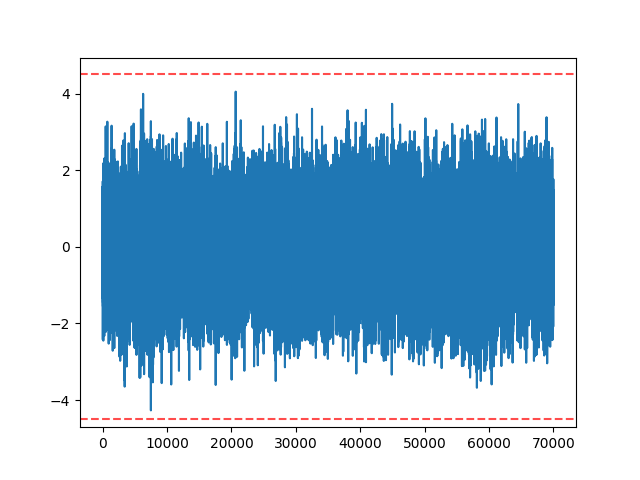

In [27]:
from matplotlib import pyplot as plt

%matplotlib widget

fig, ax = plt.subplots()

ax.plot(ttest.result)
ax.axhline(y=4.5, color='red', linestyle='--', alpha=0.7)
ax.axhline(y=-4.5, color='red', linestyle='--', alpha=0.7)